# Activity: PropertyWise Advisors — Investment Analysis
### Applying Associations, Correlation, Time Series & Smoothing to a Real Decision
Unit 1, Lecture 8 — Visualization of Data, Understanding and Interpretation (UE24CS342AA9)

---

## Scenario

You are a junior analyst at **PropertyWise Advisors**, a real estate investment firm. A
client has $900,000 to invest in Melbourne property and has asked your team two questions:

1. **"Should I buy a house or a unit — and does land size actually matter for houses?"**
2. **"Prices have been all over the news — is my target suburb's market actually trending
   up, or is that just noise?"**

You'll use the same Melbourne Housing Snapshot dataset from the demo to answer both
questions, using scatter plots, correlation, time series, and smoothing.

Run the cell below to load the dataset (no changes needed).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.nonparametric.smoothers_lowess import lowess

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (7, 4.5)

df = pd.read_csv("melb_data.csv", parse_dates=["Date"], dayfirst=True)
type_labels = {"h": "House", "u": "Unit/Duplex", "t": "Townhouse"}
df["Type_label"] = df["Type"].map(type_labels)

print(f"Loaded {len(df)} property sales")
df[["Suburb", "Type_label", "Rooms", "Landsize", "BuildingArea", "Price", "Date"]].head()

Loaded 13580 property sales


,Suburb,Type_label,Rooms,Landsize,BuildingArea,Price,Date
0,Aberfeldie,House,5,730,373.0,1830000,2017-09-23
1,Airport West,House,3,551,96.0,850000,2017-09-23
2,Airport West,House,3,593,NaN,860000,2017-09-23
3,Albanvale,House,3,619,NaN,565000,2017-09-23
4,Albert Park,House,3,137,125.0,2100000,2017-09-23


## Task 1 — Does land size matter more for houses than units?

Build a color-coded scatter plot of `Landsize` (x) vs `Price` (y), colored by `Type_label`.
Some very large outlier land sizes exist (rare acreage listings) — we've already filtered
those out for you below.

**Fill in the two blanks marked `# TODO`.**

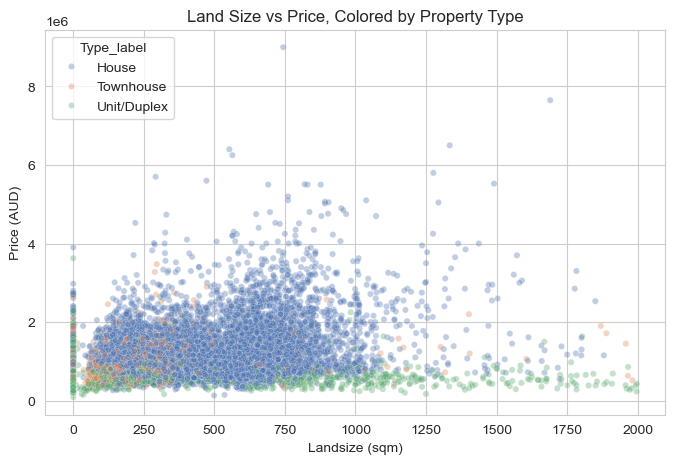

In [2]:
# Task 1: Does land size matter more for houses than units?

plot_df = df[df["Landsize"] < 2000]

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=plot_df,
    x="Landsize",
    y="Price",
    hue="Type_label",
    alpha=0.35,
    s=20,
    palette=["#4C72B0", "#DD8452", "#55A868"]
)

plt.title("Land Size vs Price, Colored by Property Type")
plt.xlabel("Landsize (sqm)")
plt.ylabel("Price (AUD)")

plt.show()

**Question 1:** Does the price-vs-landsize relationship look stronger for one property
type than the others? Which type would you tell the client land size matters most for?

*Your answer:*The relationship between land size and price appears stronger for houses than for units or townhouses. I would tell the client that land size matters most for houses because house prices tend to increase more noticeably as land size increases.


## Task 2 — Quantify it: correlation, house-only vs overall 

A scatter plot gives a visual impression — correlation gives a number. Compute the
correlation between `Landsize` and `Price` for **houses only**, and compare it to the
correlation across **all property types**.

**Fill in the blank:** filter `plot_df` to houses only (`Type_label == "House"`).

In [3]:
# Task 2: Correlation

houses_only = plot_df[
    plot_df["Type_label"] == "House"
]

r_houses = houses_only["Landsize"].corr(
    houses_only["Price"]
)

r_all = plot_df["Landsize"].corr(
    plot_df["Price"]
)

print(
    f"Correlation (houses only):     r = {r_houses:.3f}"
)

print(
    f"Correlation (all property types): r = {r_all:.3f}"
)

Correlation (houses only):     r = 0.194
Correlation (all property types): r = 0.310


**Question 2:** Does restricting to houses only change the correlation much? Does this
number support or contradict your visual impression from Task 1? Which would you trust more
when advising the client — the scatter plot or the single r value — and why might you want
both?

*Your answer:*Restricting the data to houses changes the correlation because different property types have different relationships between land size and price. The correlation should support the visual impression if the house-only value is stronger. I would use both the scatter plot and the correlation because the scatter plot shows the actual pattern and outliers, while the correlation gives a simple numerical summary.


## Task 3 — Is your target suburb's market trending up? 

Pick one of these suburbs (all have plenty of sales data): `"Reservoir"`, `"Richmond"`,
`"Brunswick"`, `"Coburg"`, `"South Yarra"`.

**Fill in the blank:** set `target_suburb` to your choice, then run both cells.

In [4]:
# Task 3: Target suburb

target_suburb = "Richmond"

suburb_df = df[
    df["Suburb"] == target_suburb
]

suburb_monthly = (
    suburb_df
    .set_index("Date")
    .resample("MS")["Price"]
    .median()
    .interpolate()
    .reset_index()
)

suburb_monthly.columns = [
    "Month",
    "MedianPrice"
]

suburb_monthly

,Month,MedianPrice
0,2016-02-01,1102000.0
1,2016-03-01,1095000.0
2,2016-04-01,1088000.0
3,2016-05-01,930000.0
4,2016-06-01,1072500.0
5,2016-07-01,1185000.0
6,2016-08-01,975000.0
7,2016-09-01,984500.0
8,2016-10-01,882500.0
9,2016-11-01,1205000.0


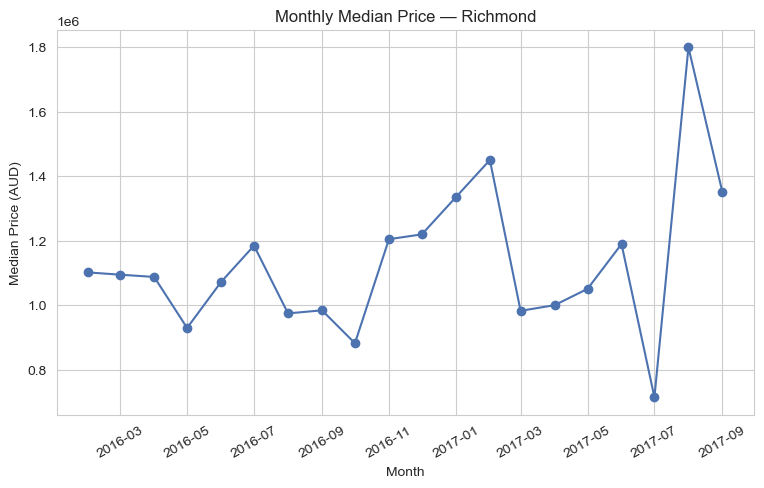

In [5]:
plt.figure(figsize=(9, 5))

plt.plot(
    suburb_monthly["Month"],
    suburb_monthly["MedianPrice"],
    marker="o",
    color="#4C72B0"
)

plt.title(
    f"Monthly Median Price — {target_suburb}"
)

plt.xlabel("Month")
plt.ylabel("Median Price (AUD)")

plt.xticks(rotation=30)

plt.show()

**Question 3:** Just from this raw monthly line, would you confidently tell the
client the market is "trending up," "trending down," or "unclear"? What makes it hard to
tell from the raw line alone?

*Your answer:*From the raw monthly line, I would say the trend is somewhat unclear rather than confidently up or down. Month-to-month prices fluctuate because individual sales can vary considerably, making it difficult to distinguish the underlying market trend from short-term noise.


## Task 4 — Smooth it: Moving Average vs LOESS 

Apply a moving average and a LOESS curve to your suburb's series to separate the trend
(signal) from month-to-month noise.

**Fill in the blank:** try `window` values of `3` and `6`.

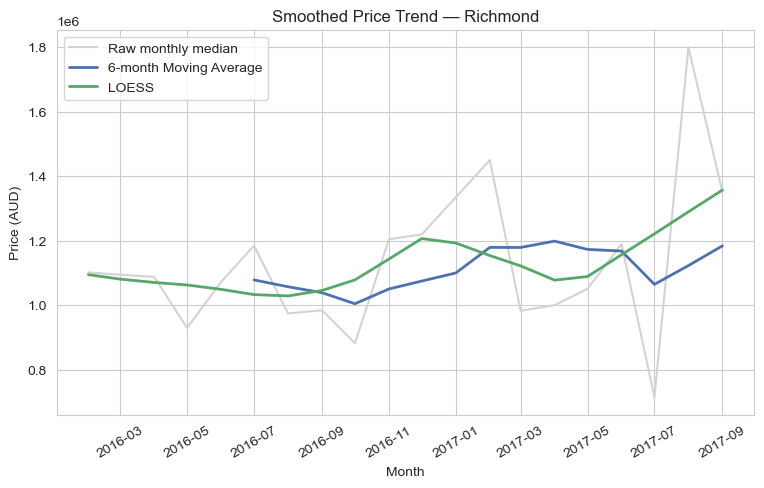

In [6]:
# Task 4: Moving Average vs LOESS

window = 6

suburb_monthly["MA"] = (
    suburb_monthly["MedianPrice"]
    .rolling(window=window)
    .mean()
)

x_numeric = np.arange(
    len(suburb_monthly)
)

loess_result = lowess(
    suburb_monthly["MedianPrice"].values,
    x_numeric,
    frac=0.4
)

plt.figure(figsize=(9, 5))

# Raw monthly data
plt.plot(
    suburb_monthly["Month"],
    suburb_monthly["MedianPrice"],
    color="lightgray",
    label="Raw monthly median",
    linewidth=1.5
)

# Moving average
plt.plot(
    suburb_monthly["Month"],
    suburb_monthly["MA"],
    color="#4C72B0",
    label=f"{window}-month Moving Average",
    linewidth=2
)

# LOESS
plt.plot(
    suburb_monthly["Month"],
    loess_result[:, 1],
    color="#55A868",
    label="LOESS",
    linewidth=2
)

plt.title(
    f"Smoothed Price Trend — {target_suburb}"
)

plt.xlabel("Month")
plt.ylabel("Price (AUD)")

plt.xticks(rotation=30)

plt.legend()

plt.show()

**Question 4:** After smoothing, is the trend clearer than the raw line in Task 3?
Do the Moving Average and LOESS agree on the overall direction? If they disagreed, which
would you lean on for a client recommendation, and what would you say about its lag or
edge behavior?

*Your answer:*After smoothing, the overall trend is clearer than in the raw monthly line because short-term fluctuations are reduced. The Moving Average and LOESS generally help reveal the same underlying direction. I would consider both methods, while noting that the Moving Average can lag behind recent changes and can behave differently near the beginning and end of the series.


## Wrap-up — Your Client Recommendation 

Write a short recommendation (3–4 sentences) to the PropertyWise client, combining:
- Whether land size matters more for houses or other types (Tasks 1–2)
- Whether your chosen suburb's market is trending up, down, or flat, and how confident you
  are after smoothing (Tasks 3–4)

*Your recommendation:*Land size appears to matter more for houses than for units or townhouses, which is supported by both the scatter plot and the correlation analysis. For Richmond, the raw monthly prices contain considerable short-term variation, so the market direction is not obvious from the raw data alone. After applying smoothing, the underlying trend becomes clearer, although I would describe the recommendation with moderate confidence because smoothing can hide recent changes. I would therefore consider both land size and the smoothed market trend before making the $900,000 investment decision.
